In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df_raw = pd.read_csv('D:/2022-2026/Project-Data Analysis/DA_Channel/data/processed/retail_dataset_cleaned.csv')
df = df_raw.copy()

# các cột flag
flag_cols = ["discount_pct_mismatch", "quantity_neg",
             "sales_amount_neg", "sales_amount_mismatch"]

# loại các bản ghi có flag là true
valid_mask = ~(df[flag_cols].any(axis=1))
df = df.loc[valid_mask].copy()

print("Số bản ghi ban đầu:", len(df_raw))
print("Số bản ghi sau khi loại bản ghi lỗi:", len(df))


Số bản ghi ban đầu: 120000
Số bản ghi sau khi loại bản ghi lỗi: 119960


In [3]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119960 entries, 0 to 119999
Data columns (total 30 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   transaction_id             119960 non-null  object        
 1   transaction_date           119960 non-null  datetime64[ns]
 2   customer_id                119960 non-null  object        
 3   customer_gender            119960 non-null  object        
 4   customer_age_group         119960 non-null  object        
 5   customer_segment           119960 non-null  object        
 6   product_id                 119960 non-null  object        
 7   product_name               119960 non-null  object        
 8   category                   119960 non-null  object        
 9   brand                      119960 non-null  object        
 10  quantity                   119960 non-null  int64         
 11  unit_price                 119960 non-null  float64      

### Tổng quan hiệu quả từng kênh

- KPI tổng hợp các kệnh

In [5]:
# Tính KPI cho từng kênh
kpi = df.groupby("sales_channel").agg(
    total_revenue=("sales_amount", "sum"),
    orders=("transaction_id", "count"),
    avg_discount=("discount_pct", "mean"),
    discount_rate=("discount_pct", lambda x: (x > 0).mean() * 100)
)

# AOV 
kpi["AOV"] = kpi["total_revenue"] / kpi["orders"]

print(kpi)

               total_revenue  orders  avg_discount  discount_rate         AOV
sales_channel                                                                
In-Store        1.593395e+07   41753      5.528824      40.353987  381.623972
Mobile App      1.275734e+07   34430      5.497241      39.753122  370.529637
Online          1.665574e+07   43777      5.462572      39.943349  380.467867


- So sánh tổng doanh thu các kênh

C:\Users\longl\AppData\Local\Temp\ipykernel_15144\355941714.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kpi.index, y=kpi["total_revenue"], palette="Blues")


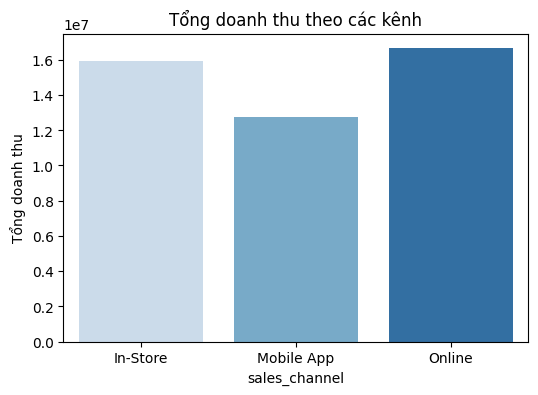

In [6]:
plt.figure(figsize=(6, 4))
sns.barplot(x=kpi.index, y=kpi["total_revenue"], palette="Blues")
plt.title("Tổng doanh thu theo các kênh")
plt.ylabel("Tổng doanh thu")
plt.show()

**Insight**
- Doanh thu của kênh `online` và `in-store` khá tương đồng, chênh nhau không đáng kể, không thể kết luận kênh nào vượt trội hơn. 
- `mobile app` có doanh thu thấp hơn nhiều so với 2 kênh còn lại 

- So sánh AOV theo kênh

C:\Users\longl\AppData\Local\Temp\ipykernel_15144\642601390.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kpi.index, y=kpi["AOV"], palette="Blues")


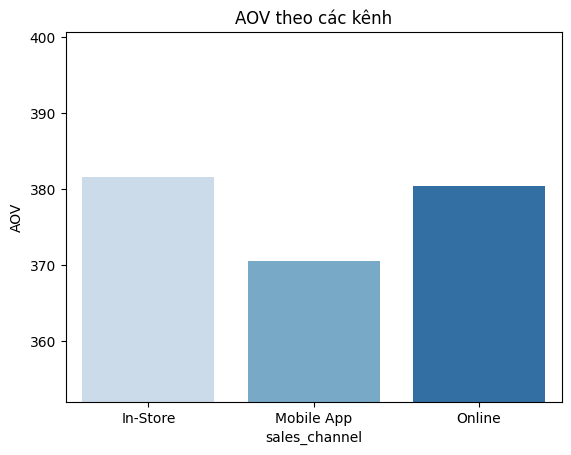

In [7]:
sns.barplot(x=kpi.index, y=kpi["AOV"], palette="Blues")
plt.ylim(kpi["AOV"].min() * 0.95, kpi["AOV"].max() * 1.05)
plt.title("AOV theo các kênh")
plt.show()

**Insight**
- AOV của `in-store` và `online` gần tương đồng nhau, chênh nhau không đáng kể. 
- `mobile app` thấp hơn đáng kể. 
- `in-store` có AOV cao nhất nhưng doanh thu không cao nhất, `in-store` it đơn hơn `online` (41.753 vs 43.777) nhưng mỗi đơn có giá trị hơn - 2 kênh mạnh theo hai hướng khác nhau. 


- Xu hướng doanh thu theo thàng

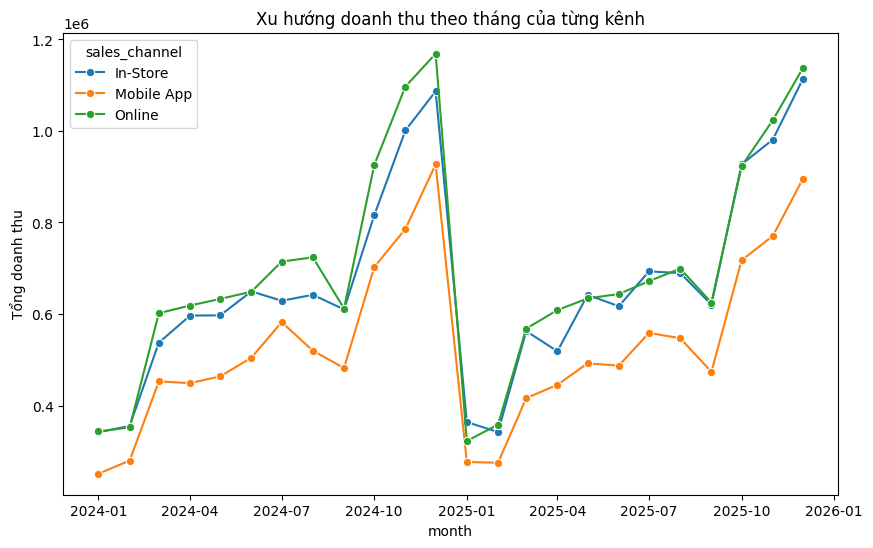

In [8]:
df["month"] = df["transaction_date"].dt.to_period("M")
monthly_revenue = df.groupby(["month", "sales_channel"])["sales_amount"].sum().reset_index()
monthly_revenue["month"] = monthly_revenue["month"].dt.to_timestamp()

plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_revenue, x="month", y="sales_amount", hue="sales_channel", marker="o")
plt.title("Xu hướng doanh thu theo tháng của từng kênh")
plt.ylabel("Tổng doanh thu")
plt.show()

**Insight**
- Doanh thu tổng tăng từ 1/2024 đến 12/2024, nhưng bắt đầu giảm mạnh đến tháng 1/2025 và có xu hướng hồi phục dần sau đó, tiếp tục tăng dần đến tháng 12/2024 chạm đỉnh doanh thu hồi tháng 12/2024.
- Kênh `online` hầu như dẫn đầu ở các tháng 
- Quý 4 ở năm 2024 và 2025 đều có xu hướng tăng mạnh.
- `mobile app` luôn thấp hơn 2 kênh còn lại ở mọi tháng, khoảng cách này không thu hẹp qua các tháng.
- Cả 3 kênh đều có xu hướng tăng và giảm giống nhau qua các tháng. 

### Phân tích phân khúc khách hàng - kênh

- Doanh thu theo từng phân khúc - kênh 

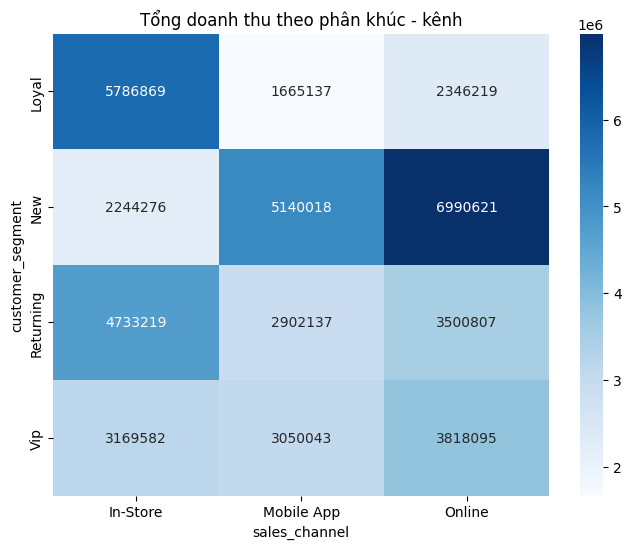

In [9]:
seg_channel_revenue = df.groupby(["customer_segment","sales_channel"])["sales_amount"].sum().unstack()

plt.figure(figsize=(8,6))
sns.heatmap(seg_channel_revenue, annot=True, fmt=".0f", cmap="Blues")
plt.title("Tổng doanh thu theo phân khúc - kênh")
plt.show()


**Insight**
- `new + online` là tổ hợp có doanh thu lớn nhất toàn bộ dữ liệu (~$7M).
- `new + mobile App` cũng đạt doanh thu cao (~$5.1M).
- Hầu hết các phân khúc đều có doanh thu cao ở kênh `online`, đặc biệt là new và vip
- `loyal + in-store` đạt doanh thu rất cao (~$5.8M), cao hơn đáng kể so với mobile app và online của cùng phân khúc.
- Ngoại trừ nhóm `new`, doanh thu Mobile App thấp hơn khá nhiều so với online và in-store


- Tỷ lệ giao dịch theo phân khúc khách hàng và kênh 

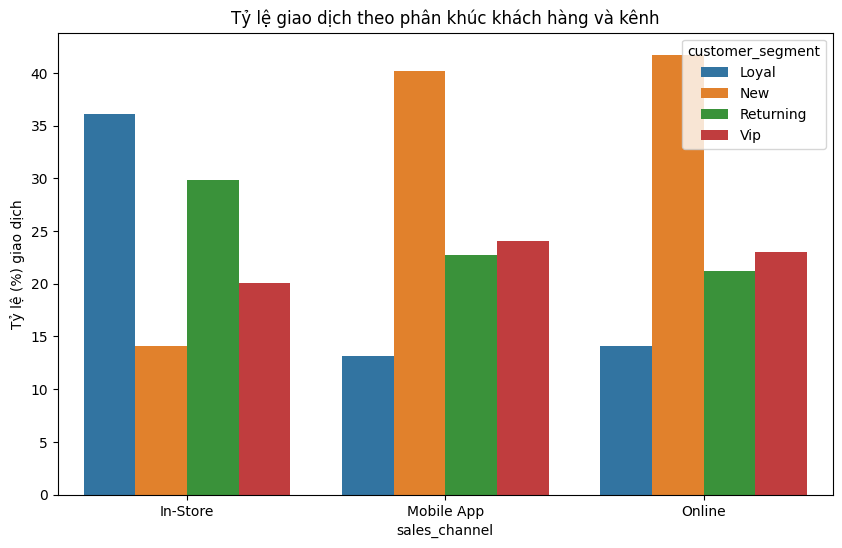

In [10]:
seg_channel_counts = df.groupby(["customer_segment", "sales_channel"])["transaction_id"].count().reset_index(name="count")
# tính % phân khúc trong từng kênh
seg_channel_counts["pct"] = seg_channel_counts.groupby("sales_channel")["count"].transform(lambda x: x/x.sum() * 100)

plt.figure(figsize=(10, 6))
sns.barplot(data=seg_channel_counts, x="sales_channel", y="pct", hue="customer_segment")
plt.title("Tỷ lệ giao dịch theo phân khúc khách hàng và kênh")
plt.ylabel("Tỷ lệ (%) giao dịch")
plt.show()

**Insight**
- `in-store`: ~36% số lượng giao dich từ loyal, chỉ ~14% từ new, đây là   kênh giữ chân khác hàng cũ, không phải kênh thu hút khách mới.
- `mobile app và online`: new chiếm ~40% và ~41%, cả 2 đều là kênh thu hút khách hàng mới, loyal chỉ chiếm ~13% trên 2 kênh này.
- Returning và VIP phân bố tương đối đều giữa 3 kênh, không kênh nào có khác biệt rõ ràng với 2 nhóm khách hàng này.     



C:\Users\longl\AppData\Local\Temp\ipykernel_15144\831294015.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new_cus['month'] = df_new_cus['month'].dt.to_timestamp()


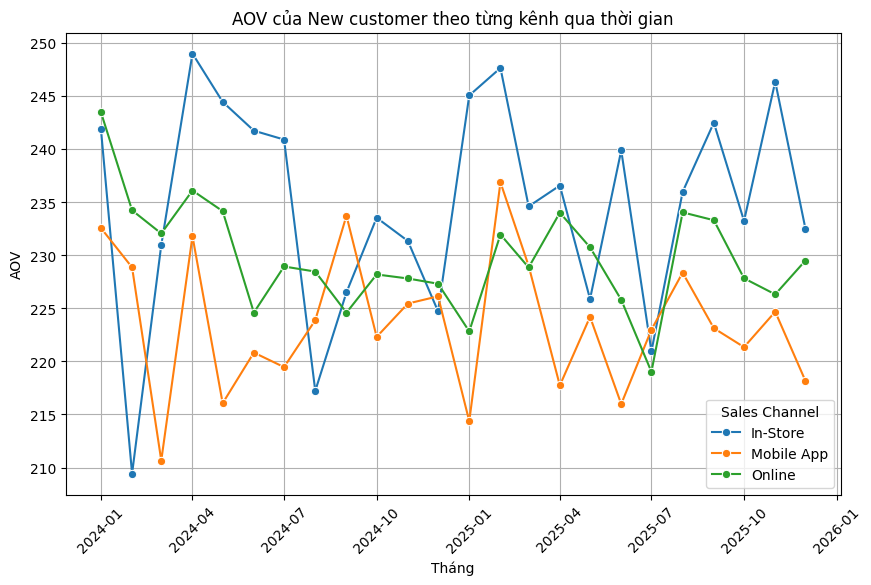

In [11]:

df['AOV'] = df['sales_amount'] / df['quantity']
df_new_cus = df[df['customer_segment'] == 'New']

df_new_cus['month'] = df_new_cus['month'].dt.to_timestamp()
aov_by_channel = (df_new_cus.groupby(['month','sales_channel'])['AOV'].mean().reset_index())

plt.figure(figsize=(10,6))
sns.lineplot(data=aov_by_channel, x="month", y="AOV", hue="sales_channel", marker="o")
plt.title('AOV của New customer theo từng kênh qua thời gian')
plt.xlabel('Tháng')
plt.ylabel('AOV')
plt.xticks(rotation=45)
plt.legend(title='Sales Channel')
plt.grid(True)
plt.show()


**Insight**
- `in-store` thường xuyên duy trì mức AOV cao hơn hai kênh còn lại, một số thời điểm AOV đạt gần 245–250.
- AOV của `mobile app` thấp nhất, có giai đoạn giảm xuống quanh mức 210.
- Kênh `online` có mức AOV tương đối ổn định quanh khoảng 220–235, không biến động mạnh như `in-store và mobile app`.
- Tuy nhiên, không có xu hướng tăng hoặc giảm dài hạn rõ rệt


- AOV theo phân khúc × kênh

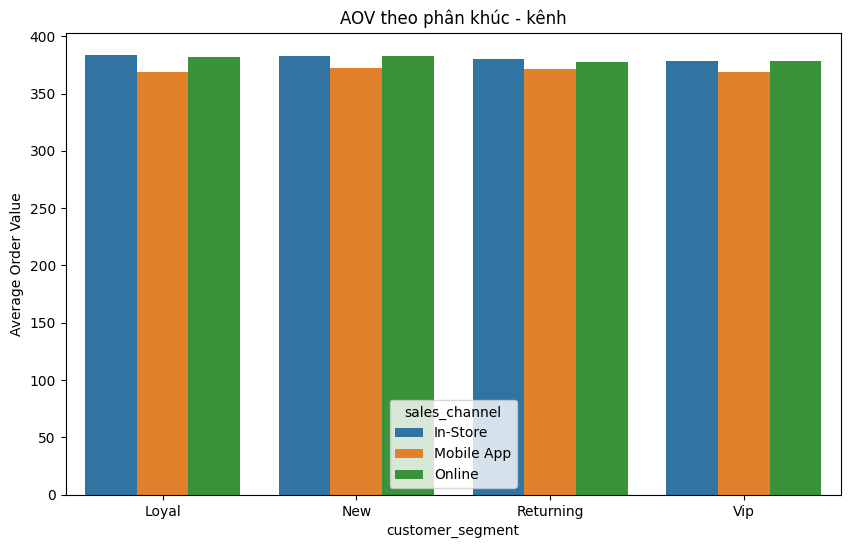

In [12]:
aov_grouped = df.groupby(["customer_segment","sales_channel"])["sales_amount"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=aov_grouped, x="customer_segment", y="sales_amount", hue="sales_channel")
plt.title("AOV theo phân khúc - kênh")
plt.ylabel("Average Order Value")
plt.show()


**Insight**
- AOV của các phân khúc khách hàng ở cả 3 kênh đều tương đối bằng nhau, không có chênh lệch rõ ràng
- `mobile app` có AOV thấp nhất ở tất cả các phân khúc. 

- Xu hướng AOV của New vs Loyal theo tháng    

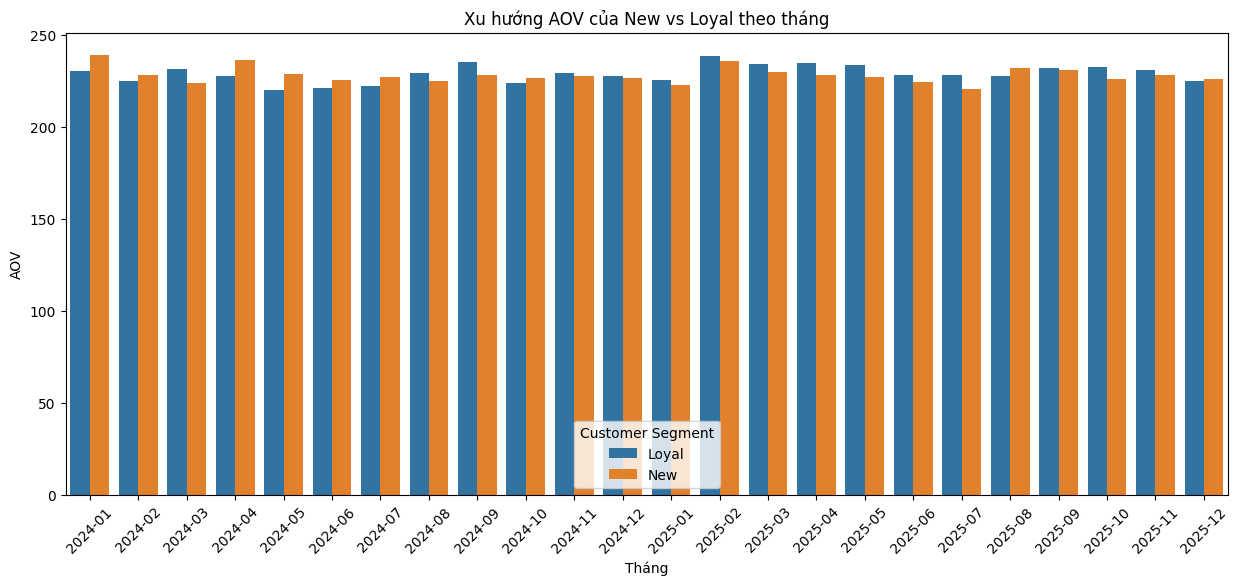

In [13]:
df["AOV"] = df["sales_amount"] / df["quantity"]
aov_month = df.groupby(["month", "customer_segment"])["AOV"].mean().reset_index()
aov_month = aov_month[aov_month["customer_segment"].isin(["New", "Loyal"])]

plt.figure(figsize=(15, 6))
sns.barplot(data=aov_month, x="month", y="AOV", hue="customer_segment") 
plt.title("Xu hướng AOV của New vs Loyal theo tháng")
plt.xlabel("Tháng")
plt.xticks(rotation = 45)
plt.legend(title="Customer Segment")
plt.show()


In [14]:
pivot_seg = aov_month.pivot(index="month", columns="customer_segment", values="AOV")
pivot_seg["chênh lệch"] = pivot_seg["Loyal"] - pivot_seg["New"]

avg_diff_seg = pivot_seg["chênh lệch"].mean()

print("Trung bình chênh lệch AOV giữa Loyal và New:", avg_diff_seg)


Trung bình chênh lệch AOV giữa Loyal và New: 0.7618044473267638


**Insight**
- AOV của các phân khúc khách hàng New và Loyal qua các tháng đều không có chênh lệch đáng kể. 
- `new` chi tiêu khá tương đồng với `loyal` và có những thời điểm đã vượt qua như: 8/2025.
- Và AOV của cả `new và loyal` hầu như không có biến động, giao động quanh 230-240

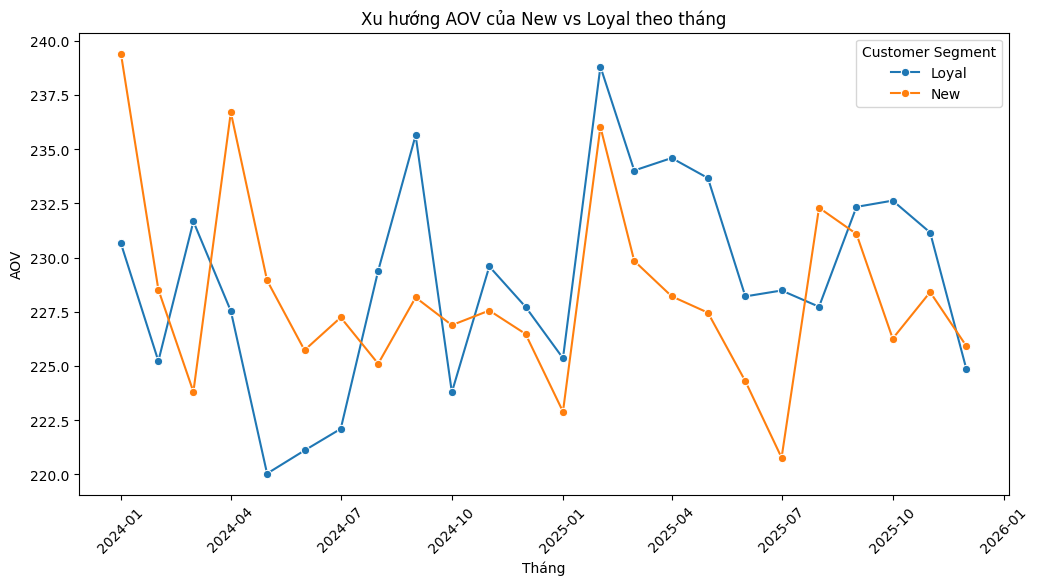

In [15]:

aov_month["month"] = aov_month["month"].dt.to_timestamp()

plt.figure(figsize=(12, 6))
sns.lineplot(data=aov_month, x="month", y="AOV", hue="customer_segment", marker="o")
plt.title("Xu hướng AOV của New vs Loyal theo tháng")
plt.xlabel("Tháng")
plt.xticks(rotation=45)
plt.legend(title="Customer Segment")
plt.show()

### Chính sách discount


- Phân phối discount theo kênh

C:\Users\longl\AppData\Local\Temp\ipykernel_15144\1328899412.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=discount_channel, x="sales_channel", y="discount_pct", palette="Blues")


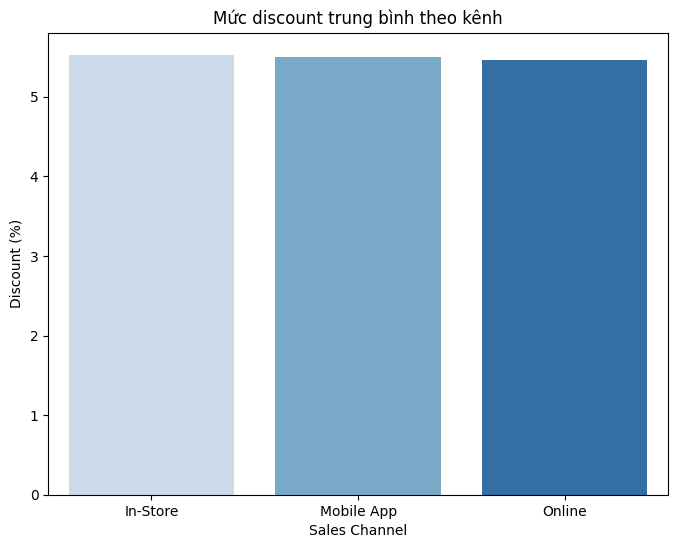

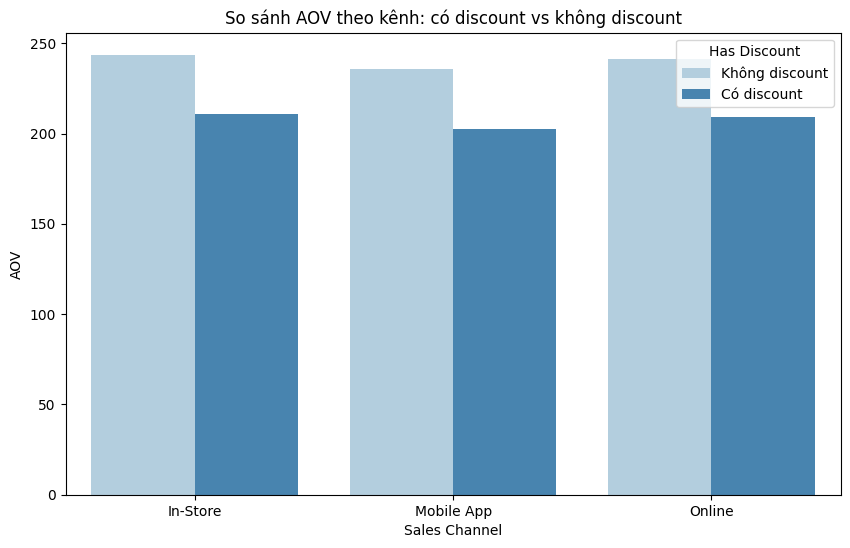

In [16]:
# discount trung bình theo kênh
discount_channel = df.groupby("sales_channel")["discount_pct"].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=discount_channel, x="sales_channel", y="discount_pct", palette="Blues")
plt.title("Mức discount trung bình theo kênh")
plt.ylabel("Discount (%)")
plt.xlabel("Sales Channel")
plt.show()

# so sánh AOV có discount vs không discount theo kênh
df["has_discount"] = df["discount_pct"] > 0
aov_discount = df.groupby(["sales_channel","has_discount"])["AOV"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=aov_discount, x="sales_channel", y="AOV", hue="has_discount", palette="Blues")
plt.title("So sánh AOV theo kênh: có discount vs không discount")
plt.ylabel("AOV")
plt.xlabel("Sales Channel")

handles, labels = plt.gca().get_legend_handles_labels()
label_map = {"False": "Không discount", "True": "Có discount"}
new_labels = [label_map[l] for l in labels]
plt.legend(handles, new_labels, title="Has Discount")
plt.show()



In [17]:
# Pivot để tách AOV theo discount
diff = aov_discount.pivot(index="sales_channel", columns="has_discount", values="AOV")

# Thêm cột chênh lệch tuyệt đối
diff["chênh lệch"] = diff[False] - diff[True]

# Thêm cột tỷ lệ % giảm
diff["% giảm"] = (diff["chênh lệch"] / diff[False]) * 100

print(diff)


has_discount        False        True  chênh lệch     % giảm
sales_channel                                               
In-Store       243.642994  210.974938   32.668056  13.408165
Mobile App     235.716481  202.763329   32.953153  13.979995
Online         241.020364  209.127069   31.893295  13.232614


**Insight**
- Discount trung bình 3 kênh gần bằng nhau.
- ~40% đơn hàng trên cả 3 kênh có sử dụng discount. 
- Discount làm giảm giá trị đơn hàng, AOV của đơn có discount thấp hơn đơn không discount.

### Phân tích danh mục sản phẩm - kênh

- Doanh thu theo doanh mục - kênh

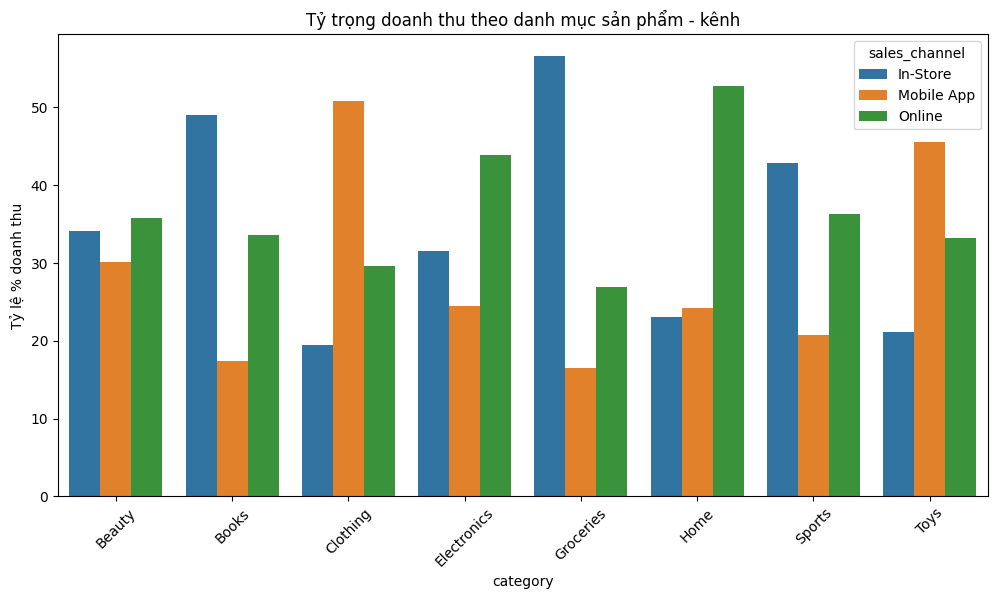

In [18]:
cat_channel = df.groupby(["category","sales_channel"])["sales_amount"].sum().reset_index(name="revenue")
cat_channel["pct"] = cat_channel.groupby("category")["revenue"].transform(lambda x: x / x.sum() * 100)

plt.figure(figsize=(12,6))
sns.barplot(data=cat_channel, x="category", y="pct", hue="sales_channel")
plt.title("Tỷ trọng doanh thu theo danh mục sản phẩm - kênh")
plt.ylabel("Tỷ lệ % doanh thu")
plt.xticks(rotation=45)
plt.show()


In [19]:
print(cat_channel)


       category sales_channel       revenue        pct
0        Beauty      In-Store  2.169748e+06  34.143319
1        Beauty    Mobile App  1.913337e+06  30.108410
2        Beauty        Online  2.271740e+06  35.748271
3         Books      In-Store  2.941813e+06  49.000463
4         Books    Mobile App  1.041984e+06  17.355860
5         Books        Online  2.019847e+06  33.643677
6      Clothing      In-Store  9.026815e+05  19.505103
7      Clothing    Mobile App  2.351729e+06  50.816054
8      Clothing        Online  1.373514e+06  29.678842
9   Electronics      In-Store  1.850936e+06  31.601404
10  Electronics    Mobile App  1.433069e+06  24.467073
11  Electronics        Online  2.573127e+06  43.931523
12    Groceries      In-Store  3.072194e+06  56.571300
13    Groceries    Mobile App  8.986197e+05  16.547161
14    Groceries        Online  1.459844e+06  26.881539
15         Home      In-Store  1.307456e+06  23.118841
16         Home    Mobile App  1.367489e+06  24.180368
17        

**Insight**
- Groceries, Sports và Books tập trung mạnh ở In-Store 
- Clothing và Toys lệch rõ về Mobile App.
- Electronics và Home lệch về Online.
- Beauty là danh mục cân bằng, chênh lệch ở mỗi kênh không đáng kể



### Câu hỏi kinh doanh

Phân tích hành vi mua hàng của khách hàng trên nhiều kênh bán hàng để so sánh hiệu quả giữa online và offline. Dự án nhằm xác định kênh bán hàng nào hiệu quả hơn và kênh nào phù hợp với từng phân khúc khách hàng.

1. Kênh nào hiệu quả nhất về doanh thu và AOV?
- Doanh thu bán ở `online` là cao nhất
- AOV của `Instore` là cao nhấy

2. Phân khúc khách hàng nào chi tiêu nhiều nhất, và đang chi tiêu ở kênh nào?
- Khách hàng `New` chi tiêu nhiều nhất ở kênh bán `Online` và `Mobile-app`
- Cả 4 nhóm khách hàng đều có AOV gần bằng nhau, ko chênh lệch và tất cả kênh đều phục vụ tốt như nhau.

3. Kênh nào đang thu hút khách mới và giữ chân khách cũ?
- In-Store: không phải kênh acquisition chính (ít khách mới hơn về tỷ lệ), nhưng khách mới ở đây lại có giá trị cao → chất lượng acquisition tốt. Nhưng mạnh về giữ chân khách hàng ở nhóm `loyal` và `returning`

- Mobile App và Online: có tỷ lệ khách mới cao, nhưng AOV thấp và không cải thiện → acquisition đang kéo về khách hàng chất lượng thấp. 

4. Khách hàng mới có đang dần chi tiêu bằng Khách hàng Loyal không?
- Khách hàng `loyal` luôn có AOV cao hơn một chút so với `New`, nhưng chênh lệch không đáng kể.
- Khách hàng `New` đang dần chi tiêu ngang bằng `Loyal` - khoảng cách AOV giữa hai nhóm nhỏ và ổn định 

5. Discount đang được sử dụng như nào cho từng kênh và có hiệu quả không?
- Cả ba kênh đều có mức giảm trung bình ~5%.
- Discount làm giảm giá trị đơn hàng, AOV của đơn có discount thường thấp hơn đơn không discount, với mức chênh lệch tương đồng nhau (~$32 mỗi kênh).
- Cho thấy chương trình khuyến mãi hiện chưa hiệu quả.

6. Sản phẩm nào bán nhiều nhất ở kênh nào?
- In-Store: nổi bật ở các danh mục Books, Groceries, Sports. 
- Mobile App: nổi bật ở các danh mục Clothing, Toys.
- Online : nổi bật ở các danh mục Electronic, Home.